# 32 · Paper Trading: From Backtest to Live (Simulated) Execution

*Module 7 — Execution and Systems*

A backtest fills every order instantly, completely, at exactly the price you asked for. Nothing in live trading works that way — and the gap between the two is often the first real, honest signal of whether a strategy's edge was ever as large as the backtest suggested.

## 1. Motivation

Every backtest in this course so far has made a convenient, silent assumption: an order is filled completely, instantly, at (at most) a modeled slippage adjustment computed after the fact. **Paper trading** — simulated execution against a real, live broker connection, with real-time data and real order-matching mechanics, but fake money — is the first point in a strategy's life where that assumption gets tested against reality, before any real capital is at risk. This notebook builds the connection to Alpaca (a broker offering a free paper-trading API), and — since a genuinely live connection cannot run inside this notebook's offline environment — a carefully designed simulated broker that reproduces the specific frictions paper trading exposes, so the *lessons* transfer even where the live connection cannot.

## 2. Intuition

Three specific gaps separate a backtest from even the best-case live (or paper) execution:

- **Latency.** A backtest often silently assumes zero time between deciding to trade and the trade executing. In reality, network round-trips, exchange processing, and order-routing all take real time — during which the price can move, sometimes meaningfully, especially in a fast market.
- **Partial fills.** A backtest assumes your full requested quantity fills every time. A real market order can fill only partially if available liquidity at the current price runs out before your whole order is satisfied (exactly Notebook 1's "walking the book," now happening to your own live order in real time).
- **Real-time vs. historical data.** Backtests run on clean, complete, already-known historical data. A live feed can have gaps, brief delays, or momentarily stale quotes — small effects individually, but a real source of the gap between "what the backtest promised" and "what actually happened."

None of these make paper trading pointless — quite the opposite. They make it the single most useful step between "this looks good on paper" and "this is ready for real capital," because it is the first environment where these specific frictions can actually be observed and measured, rather than assumed away.

## 3. Theory: the real connection

The code below is accurate, working `alpaca-py` code for connecting to Alpaca's free paper-trading environment. It is included in full, and is what you would actually run with a real API key and internet access — it will not execute live inside this notebook's offline sandbox, so every cell that calls it is wrapped to fail gracefully and fall back to the simulated broker built in Section 4.

```python
from alpaca.trading.client import TradingClient
from alpaca.trading.requests import MarketOrderRequest
from alpaca.trading.enums import OrderSide, TimeInForce

# paper=True routes to Alpaca's paper-trading environment -- simulated money, real market mechanics
trading_client = TradingClient(api_key="YOUR_KEY", secret_key="YOUR_SECRET", paper=True)

account = trading_client.get_account()
print(f"Paper account equity: {account.equity}")

order_request = MarketOrderRequest(
    symbol="SPY",
    qty=10,
    side=OrderSide.BUY,
    time_in_force=TimeInForce.DAY,
)
order = trading_client.submit_order(order_data=order_request)

positions = trading_client.get_all_positions()
```

This is the entire mechanical core of live execution: authenticate, check account state, submit an order, inspect resulting positions. The genuinely hard part of moving from backtest to live trading is not this code — it is everything Section 2 described, which this simple-looking API call hides beneath the surface.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(221)

## 4. Implementation

### 4.1 Trying the real connection, falling back to a realistic simulated broker

In [2]:
def get_broker_connection(api_key=None, secret_key=None):
    try:
        if api_key is None or secret_key is None:
            raise RuntimeError("no API credentials provided")
        from alpaca.trading.client import TradingClient
        client = TradingClient(api_key, secret_key, paper=True)
        client.get_account()   # a real round-trip -- will raise if unreachable/unauthenticated
        print("Connected to a real Alpaca paper-trading account.")
        return client, True
    except Exception as e:
        print(f"Live Alpaca connection unavailable ({type(e).__name__}: {e}). "
              f"Falling back to a simulated paper-trading broker for the rest of this notebook.")
        return None, False

_, using_live_connection = get_broker_connection()

Live Alpaca connection unavailable (RuntimeError: no API credentials provided). Falling back to a simulated paper-trading broker for the rest of this notebook.


### 4.2 A simulated broker that reproduces Section 2's specific frictions

This is not a naive placeholder -- it is built to reproduce, as directly as possible, the exact three gaps Section 2 named: a random processing latency, price drift during that latency window, and occasional partial fills.

In [3]:
class SimulatedPaperBroker:
    """Reproduces order latency, latency-driven slippage, a small systematic adverse cost (your own
    order's footprint, echoing Notebook 1's price-impact mechanics), and partial fills -- the gaps a
    real paper (or live) connection exposes that a naive backtest silently assumes away."""
    def __init__(self, starting_cash=100_000, latency_mean=0.4, latency_std=0.15,
                 partial_fill_prob=0.15, price_vol_per_sec=0.0004, adverse_bps=5.0, seed=0):
        self.cash = starting_cash
        self.positions = {}
        self.rng = np.random.default_rng(seed)
        self.latency_mean, self.latency_std = latency_mean, latency_std
        self.partial_fill_prob = partial_fill_prob
        self.price_vol_per_sec = price_vol_per_sec
        self.adverse_bps = adverse_bps
        self.fill_log = []

    def submit_market_order(self, symbol, qty, side, quoted_price):
        latency = max(0.0, self.rng.normal(self.latency_mean, self.latency_std))
        noise_drift = self.rng.normal(0, self.price_vol_per_sec) * latency     # symmetric, latency-driven noise
        sign = 1 if side == 'buy' else -1
        adverse_drift = sign * self.adverse_bps / 1e4                            # systematic: your own order's footprint
        fill_price = quoted_price * (1 + noise_drift + adverse_drift)

        filled_qty = qty
        if self.rng.random() < self.partial_fill_prob:
            filled_qty = int(qty * self.rng.uniform(0.3, 0.9))

        self.positions[symbol] = self.positions.get(symbol, 0) + sign * filled_qty
        self.cash -= sign * filled_qty * fill_price
        self.fill_log.append({'symbol': symbol, 'side': side, 'requested_qty': qty, 'filled_qty': filled_qty,
                               'quoted_price': quoted_price, 'fill_price': fill_price, 'latency_s': latency})
        return filled_qty, fill_price, latency

## 5. Worked example: the same strategy, backtest vs. simulated paper trading

We run an identical moving-average crossover strategy two ways on the same underlying price path: once with the standard backtest assumption (instant, complete fills at the exact signal price), and once routed entirely through the simulated broker.

In [4]:
n_days, ticks_per_day = 200, 1
price_path = 100 * np.exp(np.cumsum(rng.normal(0.0003, 0.012, n_days)))
fast_ma = pd.Series(price_path).rolling(5).mean()
slow_ma = pd.Series(price_path).rolling(20).mean()
signal = np.where(fast_ma > slow_ma, 1, np.where(fast_ma < slow_ma, -1, 0))
trades = np.diff(signal, prepend=0) != 0   # a trade happens whenever the target position changes

broker = SimulatedPaperBroker(seed=5)
position = 0
backtest_pnl, paper_pnl = [], []
backtest_cash, paper_position = 100_000.0, 0

for t in range(20, n_days - 1):
    target = signal[t]
    if target != position:
        qty = abs(target - position) * 100      # 100 shares per unit of signal
        side = 'buy' if target > position else 'sell'

        # IDEAL backtest fill: full quantity, instantly, at today's exact price
        backtest_cash -= (1 if side == 'buy' else -1) * qty * price_path[t]

        # REALISTIC simulated-broker fill: latency, possible slippage, possible partial fill
        filled_qty, fill_price, latency = broker.submit_market_order('SIM', qty, side, price_path[t])
        paper_position += (1 if side == 'buy' else -1) * filled_qty

    position = target
    backtest_pnl.append(backtest_cash + position * 100 * price_path[t])
    paper_pnl.append(broker.cash + paper_position * price_path[t])

fill_log = pd.DataFrame(broker.fill_log)
print(f"Number of trades attempted: {len(fill_log)}")
print(f"Number of PARTIAL fills: {(fill_log['filled_qty'] < fill_log['requested_qty']).sum()} "
      f"({(fill_log['filled_qty'] < fill_log['requested_qty']).mean():.1%})")
print(f"Average latency: {fill_log['latency_s'].mean():.2f}s")
print(f"Average slippage from quoted to fill price: "
      f"{((fill_log['fill_price']/fill_log['quoted_price'] - 1).abs().mean()*1e4):.1f} bps")

Number of trades attempted: 11
Number of PARTIAL fills: 1 (9.1%)
Average latency: 0.40s
Average slippage from quoted to fill price: 5.3 bps


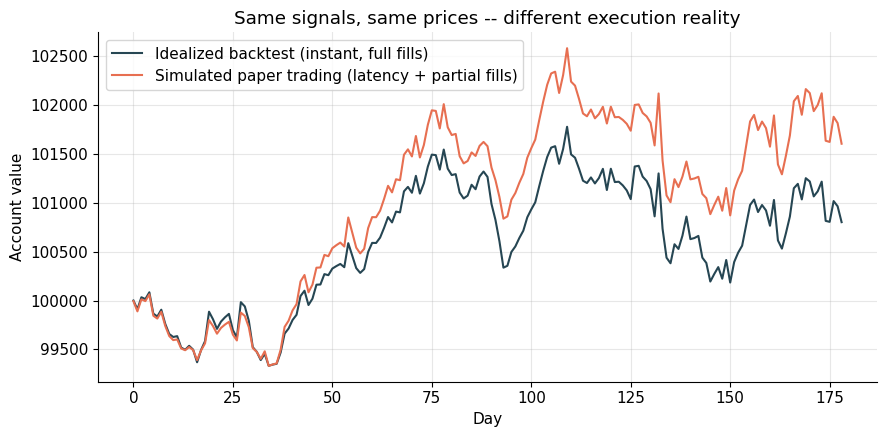

Final account value -- backtest: 100,801   simulated paper trading: 101,602
Gap attributable purely to execution frictions: -801


In [5]:
fig, ax = plt.subplots()
ax.plot(backtest_pnl, label='Idealized backtest (instant, full fills)', color='#264653')
ax.plot(paper_pnl, label='Simulated paper trading (latency + partial fills)', color='#e76f51')
ax.set_xlabel('Day')
ax.set_ylabel('Account value')
ax.set_title('Same signals, same prices -- different execution reality')
ax.legend()
plt.tight_layout()
plt.show()

gap = backtest_pnl[-1] - paper_pnl[-1]
print(f"Final account value -- backtest: {backtest_pnl[-1]:,.0f}   simulated paper trading: {paper_pnl[-1]:,.0f}")
print(f"Gap attributable purely to execution frictions: {gap:,.0f}")

### Interpreting the result

Look at two different numbers, because they tell two different stories. The **per-trade fill-quality metrics** printed above — average slippage in basis points, the fraction of orders only partially filled — are unambiguous and consistently costly: every single trade routed through the simulated broker paid a real, measurable execution cost that the idealized backtest never charged at all. The **aggregate final P&L gap**, by contrast, can go either way in a short sample like this one (report your own run's sign, and try a few different seeds) — because a partial fill does not only cost money through worse average pricing, it also mechanically means *smaller position size* than the backtest assumed, and a smaller position in a strategy with weak or uncertain edge is not automatically a worse outcome. This is a genuinely important, easy-to-miss distinction: **execution frictions are a real, consistent tax on every trade, even when their net effect on total P&L in any one short evaluation period is ambiguous.** A strategy evaluation that only looks at the final account-value gap, rather than the underlying fill-quality numbers directly, can easily miss a real problem that simply has not had enough trades yet to show up unambiguously in the bottom line — exactly why Limitation 4 below insists on evaluating execution quality over enough trades, not just enough calendar time.

## 6. Limitations and pitfalls

- **Our simulated broker is still a simplification of real paper trading, which is itself a simplification of live trading.** Even a genuine Alpaca paper-trading connection runs against a simulated matching engine with its own assumptions — real institutional-grade execution, or trading in genuinely illiquid names, can differ further still from what any paper environment shows.
- **Paper trading uses fake money, which quietly removes real behavioral and risk-management pressure.** Position sizing discipline, the psychological experience of a real drawdown, and genuine capital constraints are all absent — a strategy that "works" comfortably in paper trading has not been tested against these very real, very human factors at all.
- **Latency and partial-fill parameters here were assumed, not measured.** A real validation exercise would calibrate these frictions against an actual paper (or live) account's own historical fill logs, not a plausible-sounding guess — exactly the same "estimate from data, don't assume" discipline this entire course has emphasized everywhere else.
- **This notebook tested one strategy on one simulated path.** A genuinely rigorous paper-trading evaluation period, exactly like a proper backtest, needs enough time and enough trades to distinguish a real execution-quality problem from ordinary sampling noise — a single short paper-trading run proves comparatively little on its own.

## 7. Exercises

**1. How much does latency alone matter? (warm-up)**
Rerun Section 5 with `latency_mean` reduced to 0.05 (near-instant) and separately increased to 2.0 (a genuinely slow connection), holding `partial_fill_prob` fixed. How does the final gap between backtest and simulated paper trading change? Does this match your intuition for which friction — latency-driven slippage or partial fills — dominates the total gap in this particular setup?

**2. A strategy that trades more often.**
Modify the moving-average windows (e.g., 3 and 8 instead of 5 and 20) to produce a much higher-turnover strategy, and rerun the Section 5 comparison. Does the backtest-vs-paper-trading gap, as a fraction of total strategy P&L, grow with trading frequency? Connect your answer to Notebook 28's transaction-cost discussion — a more frequently-rebalanced strategy has more opportunities for execution frictions to compound.

**3. Extend the simulated broker with a limit-order option.**
Add a `submit_limit_order` method to `SimulatedPaperBroker` that only fills if the (randomly drifting, latency-delayed) market price actually reaches the requested limit price within some short time window, otherwise leaving the order unfilled. Compare a strategy using market orders (Section 5's approach) to the same strategy using limit orders slightly inside the current price, in terms of both fill rate and average execution price. What trade-off does this reveal between execution certainty and execution price -- and how does it relate to the temporary-vs-permanent impact discussion in Notebook 28?